# 05 — INTEGRAÇÃO, ANÁLISE EXPLORATÓRIA E TREINAMENTO: Dengue com sinais de alarme ou dengue grave (SINAN 2025)

Este notebook consome **apenas a camada tratada** produzida pelos notebooks de limpeza (`01_limpeza_sinan`, `02_limpeza_cnes`, `03_limpeza_ibge`) e corresponde aos processos **P03 a P05 e P07** do Mapeamento de Processos: reserva do conjunto de teste, exploração dos dados de desenvolvimento, integração das fontes tabulares e um primeiro ajuste comparando o SINAN isolado com o SINAN enriquecido. Segue o modelo de notebook usado no Projeto Aplicado I: cada etapa traz o texto do que foi feito, o código e a interpretação das saídas.

**Projeto Aplicado II — Guilherme Cunha Oliveira (RA 10754621) e Gabriel Lucca Simionato (RA 10751300)**

---

## APRESENTAÇÃO DOS DADOS

**Entradas (camada `db/bases_tratadas/`):**

| Fonte | Arquivo tratado | Produzido por | Granularidade |
|---|---|---|---|
| SINAN / Dengue 2025 | `sinan/sinan_dengue_2025_tratado.parquet` (cópia do CSV) | `01_limpeza_sinan.ipynb` | um caso elegível (CLASSI_FIN 10, 11 ou 12), com o alvo e as variáveis já recodificadas |
| CNES / Leitos 2025 | `cnes/cnes_municipio_2025_tratado.csv` | `02_limpeza_cnes.ipynb` | município × competência mensal |
| IBGE / Censo 2022 | `ibge/ibge_municipio_2022_tratado.csv` | `03_limpeza_ibge.ipynb` | um município |
| SINAN auditoria | `sinan/sinan_dengue_2025_auditoria.csv` | `01_limpeza_sinan.ipynb` | campos que revelam o desfecho — usados só para demonstrar o vazamento, nunca como preditores |

A trilha textual (`04_limpeza_informes.ipynb`) produz o corpus dos informes e será analisada em notebook próprio (P06).

**Origem dos dados e contexto do problema:**
A dengue é o agravo de notificação compulsória com maior volume de registros no Brasil. A maior parte dos casos evolui sem complicações, mas uma fração é classificada como *dengue com sinais de alarme* ou *dengue grave*, condições que exigem atenção hospitalar e concentram os óbitos. Entender quais perfis de casos e de contexto municipal estão associados a essas classificações é o problema analítico definido na Etapa 1.

**O que cada linha representa:** na base analítica, um caso elegível de dengue com início de sintomas nas semanas epidemiológicas de 2025, com seus atributos da ficha e o contexto do município de residência na competência dos primeiros sintomas.

**Significado das principais variáveis (nomes da camada tratada):**
- `alvo`: 0 = dengue (CLASSI_FIN 10); 1 = dengue com sinais de alarme ou grave (11, 12).
- `idade_anos`, `sexo`, `gestante`, `raca`, `escolaridade`: perfil demográfico decodificado, com "ignorado" e "não se aplica" como categorias.
- `FEBRE_bin` … `DOR_RETRO_bin` (14) e `DIABETES_bin` … `AUTO_IMUNE_bin` (7): sintomas e comorbidades em 0/1, com ignorado como nulo.
- `dias_ate_notificacao`, `mes_sintomas`, `competencia`, `uf_res`, `cod_municipio`: tempo, sazonalidade e localidade.
- `leitos`, `leitos_sus`, `leitos_uti`, `leitos_uti_sus`, `n_estabelecimentos` (CNES): capacidade instalada cadastrada no município, na competência do caso. Não representam leitos livres.
- `populacao`, `area_km2`, `densidade_hab_km2`, `domicilios_ocupados`, `media_moradores`, `regiao` (IBGE): contexto municipal de 2022.

**Possível aplicação do dataset:**
Um modelo que aponte, a partir do que está disponível no momento da notificação, quais perfis têm maior probabilidade de evoluir para alarme ou gravidade poderia apoiar a priorização de acompanhamento e o planejamento de leitos — uma aplicação potencial, não demonstrada neste projeto. As associações encontradas não demonstram causa nem risco individual, e nenhuma utilidade clínica é prometida.

## ETAPA 1: Bibliotecas, ambiente e reprodutibilidade

Importamos as bibliotecas definidas no mapeamento e no roteiro complementar — **pandas** e **NumPy** para manipulação, **Matplotlib** para os gráficos, **scikit-learn** para o pré-processamento, o modelo e as métricas — e fixamos a semente (`SEED = 42`) usada em todas as divisões aleatórias. Os caminhos são relativos à raiz do repositório: entradas em `db/bases_tratadas/`, saídas em `db/bases_tratadas/analitica/` e figuras em `reports/figuras/`.

In [1]:
import sys, platform, json, hashlib, gc, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.dpi": 100})

def barras(ax, rotulos, valores, titulo, xlabel="", ylabel="", cor="steelblue", linha=None):
    ax.bar([str(r) for r in rotulos], valores, color=cor)
    if linha is not None: ax.axhline(linha, ls="--", c="gray", label="média geral"); ax.legend()
    ax.set_title(titulo); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
pd.set_option("display.width", 160, "display.max_columns", 60, "display.max_rows", 120)

SEED = 42
np.random.seed(SEED)

RAIZ = Path("..").resolve()
TRATADA = RAIZ/"db/bases_tratadas"
PROC, FIG = TRATADA/"analitica", RAIZ/"reports/figuras"
for p in (PROC, FIG): p.mkdir(parents=True, exist_ok=True)

print("Python", platform.python_version())
for m in (np, pd, matplotlib, sklearn): print(f"{m.__name__:12s} {m.__version__}")

Python 3.12.3
numpy        2.4.4
pandas       3.0.2
matplotlib   3.10.8
sklearn      1.8.0


## ETAPA 2: Integridade das entradas tratadas

Registramos a identidade (tamanho, linhas e SHA-256) dos arquivos da camada tratada que alimentam este notebook. Como os notebooks de limpeza já registraram a identidade dos brutos nos seus logs, a cadeia bruto → tratado → analítico fica inteira documentada, atendendo à dimensão **Integridade e origem** do mapeamento.

In [2]:
def sha256(caminho, bloco=1 << 24):
    h = hashlib.sha256()
    with open(caminho, "rb") as f:
        for parte in iter(lambda: f.read(bloco), b""): h.update(parte)
    return h.hexdigest()

ENTRADAS = {"SINAN tratado": TRATADA/"sinan/sinan_dengue_2025_tratado.parquet",
            "SINAN auditoria": TRATADA/"sinan/sinan_dengue_2025_auditoria.csv",
            "CNES tratado": TRATADA/"cnes/cnes_municipio_2025_tratado.csv",
            "IBGE tratado": TRATADA/"ibge/ibge_municipio_2022_tratado.csv"}
registro = pd.DataFrame([{"fonte": k, "arquivo": str(p.relative_to(RAIZ)), "tamanho_MB": round(p.stat().st_size/1e6, 1), "sha256": sha256(p)} for k, p in ENTRADAS.items()])
registro.to_csv(PROC/"integridade_entradas_tratadas.csv", index=False)
for k, p in ENTRADAS.items(): assert p.exists(), f"execute o notebook de limpeza que gera {p.name}"
registro

,fonte,arquivo,tamanho_MB,sha256
0,SINAN tratado,db/bases_tratadas/sinan/sinan_dengue_2025_trat...,30.0,87c089ceb0bdfed73af727da97cc2af2fa80a9319a71c6...
1,SINAN auditoria,db/bases_tratadas/sinan/sinan_dengue_2025_audi...,163.6,7a0a5e6e02b9de4b073246fa64710f12b35a9ce4a9ef9b...
2,CNES tratado,db/bases_tratadas/cnes/cnes_municipio_2025_tra...,1.1,ac583135584ecee2dfa88804397e87b525d8ce681b4d88...
3,IBGE tratado,db/bases_tratadas/ibge/ibge_municipio_2022_tra...,0.4,80367eb9809ffa0d977e478bc1a1db7e761ed7b64446fc...


## ETAPA 3: Leitura da camada tratada (P02 concluído nos notebooks de limpeza)

O SINAN tratado já vem com uma linha por caso elegível, o alvo construído e as variáveis recodificadas; aqui só conferimos a estrutura e os totais registrados no log do notebook 01. O CNES e o IBGE tratados são pequenos e cabem inteiros na memória.

In [3]:
SINTOMAS = ["FEBRE","MIALGIA","CEFALEIA","EXANTEMA","VOMITO","NAUSEA","DOR_COSTAS","CONJUNTVIT","ARTRITE","ARTRALGIA","PETEQUIA_N","LEUCOPENIA","LACO","DOR_RETRO"]
COMORB   = ["DIABETES","HEMATOLOG","HEPATOPAT","RENAL","HIPERTENSA","ACIDO_PEPT","AUTO_IMUNE"]
SINT_BIN, COMORB_BIN = [c+"_bin" for c in SINTOMAS], [c+"_bin" for c in COMORB]

t0 = time.time()
sinan = pd.read_parquet(ENTRADAS["SINAN tratado"])
for c in ["sexo","gestante","raca","escolaridade","uf_res","cod_municipio"]: sinan[c] = sinan[c].astype("category")
log01 = json.loads((TRATADA/"sinan/sinan_limpeza_log.json").read_text(encoding="utf-8"))
print(f"SINAN tratado: {sinan.shape} | memória {sinan.memory_usage(deep=True).sum()/1e6:.0f} MB | {time.time()-t0:.0f} s")
print("Contagens registradas na limpeza (notebook 01):"); print(pd.Series(log01["etapas"]["alvo"]).to_string())
sinan.head()

SINAN tratado: (1481802, 48) | memória 256 MB | 2 s
Contagens registradas na limpeza (notebook 01):
total_original                 1643215
duplicatas_exatas_removidas        620
dengue_10                      1444010
dengue_sinais_alarme_11          35105
dengue_grave_12                   2687
inconclusivo_8                  157976
codigo_0_invalido                 1642
descartado_5                         0
sem_classificacao_nulo            1175
excluidos_por_classificacao     160793
base_final_elegivel            1481802


,id_registro,DT_NOTIFIC,DT_SIN_PRI,SEM_NOT,SEM_PRI,NU_ANO,NU_IDADE_N,idade_anos,CS_SEXO,sexo,CS_GESTANT,gestante,CS_RACA,raca,CS_ESCOL_N,escolaridade,ocupacao_cbo,SG_UF,uf_res,ID_MN_RESI,cod_municipio,FEBRE_bin,MIALGIA_bin,CEFALEIA_bin,EXANTEMA_bin,VOMITO_bin,NAUSEA_bin,DOR_COSTAS_bin,CONJUNTVIT_bin,ARTRITE_bin,ARTRALGIA_bin,PETEQUIA_N_bin,LEUCOPENIA_bin,LACO_bin,DOR_RETRO_bin,DIABETES_bin,HEMATOLOG_bin,HEPATOPAT_bin,RENAL_bin,HIPERTENSA_bin,ACIDO_PEPT_bin,AUTO_IMUNE_bin,dias_ate_notificacao,mes_sintomas,competencia,CLASSI_FIN,alvo,flag_possivel_duplicidade
0,0,2024-12-29,2024-12-29,202501.0,202501.0,2024.0,4021.0,21.0,M,M,6.0,nao_se_aplica,4.0,parda,6.0,medio_completo,10001,32.0,32,320070.0,320070,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12,202412,10.0,0,0
1,1,2024-12-29,2024-12-29,202501.0,202501.0,2024.0,4072.0,72.0,F,F,5.0,nao,1.0,branca,1.0,fund_incompleto,999990,32.0,32,320020.0,320020,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,12,202412,10.0,0,0
2,2,2024-12-29,2024-12-29,202501.0,202501.0,2024.0,4073.0,73.0,M,M,6.0,nao_se_aplica,4.0,parda,1.0,fund_incompleto,999990,32.0,32,320020.0,320020,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12,202412,10.0,0,0
3,3,2024-12-29,2024-12-29,202501.0,202501.0,2024.0,4011.0,11.0,F,F,5.0,nao,4.0,parda,3.0,fund_incompleto,999992,32.0,32,320020.0,320020,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12,202412,10.0,0,0
4,4,2024-12-29,2024-12-29,202501.0,202501.0,2024.0,4026.0,26.0,M,M,6.0,nao_se_aplica,1.0,branca,5.0,medio_incompleto,761240,32.0,32,320020.0,320020,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12,202412,10.0,0,0


In [4]:
sinan.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1481802 entries, 0 to 1481801
Data columns (total 48 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   id_registro                1481802 non-null  int64         
 1   DT_NOTIFIC                 1481802 non-null  datetime64[us]
 2   DT_SIN_PRI                 1481802 non-null  datetime64[us]
 3   SEM_NOT                    1481802 non-null  float32       
 4   SEM_PRI                    1481802 non-null  float32       
 5   NU_ANO                     1481802 non-null  float32       
 6   NU_IDADE_N                 1481802 non-null  float32       
 7   idade_anos                 1481763 non-null  float32       
 8   CS_SEXO                    1481802 non-null  category      
 9   sexo                       1481802 non-null  category      
 10  CS_GESTANT                 1481641 non-null  float32       
 11  gestante                   1481802 non-null  cat

In [5]:
cnes = pd.read_csv(ENTRADAS["CNES tratado"], dtype={"cod_municipio": str})
ibge = pd.read_csv(ENTRADAS["IBGE tratado"], dtype={"cod_municipio": str, "cd_mun_ibge7": str})
print("CNES tratado:", cnes.shape, "| chave única:", not cnes.duplicated(["cod_municipio","competencia"]).any(), "| competências:", cnes.competencia.min(), "->", cnes.competencia.max())
print("IBGE tratado:", ibge.shape, "| chave única:", ibge.cod_municipio.is_unique)
display(cnes.head(3)); ibge.head(3)

CNES tratado: (42552, 7) | chave única: True | competências: 202501 -> 202512
IBGE tratado: (5570, 10) | chave única: True


,cod_municipio,competencia,n_estabelecimentos,leitos,leitos_sus,leitos_uti,leitos_uti_sus
0,110001,202501,2,57,51,0,0
1,110001,202502,2,57,51,0,0
2,110001,202503,2,57,51,0,0


,cod_municipio,cd_mun_ibge7,nome_municipio,uf,regiao,populacao,area_km2,domicilios_ocupados,media_moradores,densidade_hab_km2
0,110001,1100015,Alta Floresta D'Oeste,Rondônia,Norte,21494,7067.126782,7699,2.8,3.04
1,110002,1100023,Ariquemes,Rondônia,Norte,96833,4426.143126,34784,2.8,21.88
2,110003,1100031,Cabixi,Rondônia,Norte,5351,1314.351845,1967,2.7,4.07


## ETAPA 4: Alvo e desequilíbrio (P03)

O alvo já vem construído da limpeza (CLASSI_FIN 10 → 0; 11 e 12 → 1). Conferimos a distribuição, porque ela condiciona todo o restante: apenas **2,55%** dos casos são positivos. Um modelo que classificasse tudo como "dengue" acertaria 97,45% e seria inútil; por isso a acurácia simples não pode ser a única medida (Etapa 14) e o treinamento usará ponderação de classes (Etapa 13).

                  n      %
CLASSI_FIN                
10.0        1444010  97.45
11.0          35105   2.37
12.0           2687   0.18

casos elegíveis: 1,481,802 | positivos: 37,792 (2.55%)


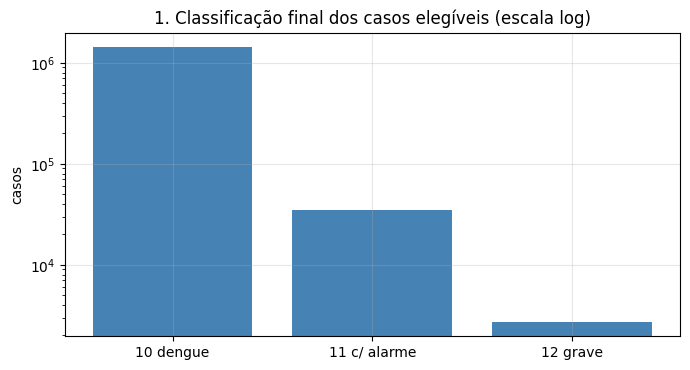

In [6]:
dist = sinan.CLASSI_FIN.value_counts().sort_index()
print(pd.DataFrame({"n": dist, "%": (dist/dist.sum()*100).round(2)}).to_string())
print(f"\ncasos elegíveis: {len(sinan):,} | positivos: {int(sinan.alvo.sum()):,} ({sinan.alvo.mean()*100:.2f}%)")
plt.figure(figsize=(7, 3.8))
barras(plt.gca(), ["10 dengue","11 c/ alarme","12 grave"], dist.values, "1. Classificação final dos casos elegíveis (escala log)", ylabel="casos")
plt.yscale("log")
plt.tight_layout(); plt.savefig(FIG/"01_classi_fin.png", dpi=120); plt.show()

## ETAPA 5: Variáveis que revelam o alvo (validade temporal)

A limpeza separou em `sinan_dengue_2025_auditoria.csv` os campos posteriores à notificação ou que definem a classificação. Aqui mostramos, com os próprios dados, por que eles não podem ser preditores: quase todos os positivos têm ao menos um sinal de alarme marcado, e quase nenhum negativo tem. Os sinais de alarme (`ALRM_*`) e de gravidade (`GRAV_*`) são os critérios clínicos da classificação 11 e 12; hospitalização, evolução e óbito acontecem depois. Só entram atributos disponíveis no momento da notificação.

In [7]:
ALARME = ["ALRM_HIPOT","ALRM_PLAQ","ALRM_VOM","ALRM_SANG","ALRM_HEMAT","ALRM_ABDOM","ALRM_LETAR","ALRM_HEPAT","ALRM_LIQ"]
GRAVID = ["GRAV_PULSO","GRAV_CONV","GRAV_ENCH","GRAV_INSUF","GRAV_TAQUI","GRAV_EXTRE","GRAV_HIPOT","GRAV_HEMAT","GRAV_MELEN","GRAV_METRO","GRAV_SANG","GRAV_AST","GRAV_MIOC","GRAV_CONSC","GRAV_ORGAO"]
aud = pd.read_csv(ENTRADAS["SINAN auditoria"], usecols=["id_registro","alvo","HOSPITALIZ"] + ALARME + GRAVID, dtype="float32")
aud["alarme_qualquer"] = (aud[ALARME] == 1).any(axis=1); aud["gravidade_qualquer"] = (aud[GRAVID] == 1).any(axis=1)
print("alvo x algum sinal de alarme = 1"); print(pd.crosstab(aud.alvo, aud.alarme_qualquer, margins=True))
print("\nalvo x algum sinal de gravidade = 1"); print(pd.crosstab(aud.alvo, aud.gravidade_qualquer, margins=True))
print("\nalvo x HOSPITALIZ (1 sim, 2 não, 9 ignorado)"); print(pd.crosstab(aud.alvo, aud.HOSPITALIZ.fillna(-1).astype(int), margins=True))
del aud; gc.collect();

alvo x algum sinal de alarme = 1
alarme_qualquer    False   True      All
alvo                                    
0.0              1441459   2551  1444010
1.0                 1228  36564    37792
All              1442687  39115  1481802

alvo x algum sinal de gravidade = 1


gravidade_qualquer    False  True      All
alvo                                      
0.0                 1443822   188  1444010
1.0                   35147  2645    37792
All                 1478969  2833  1481802

alvo x HOSPITALIZ (1 sim, 2 não, 9 ignorado)
HOSPITALIZ      -1  0      1        2      9      All
alvo                                                 
0.0         244095  2  45348  1127525  27040  1444010
1.0           2568  0  23380    11515    329    37792
All         246663  2  68728  1139040  27369  1481802


## ETAPA 6: Reserva do conjunto de teste (P03)

O mapeamento prevê "definir casos elegíveis e reservar a avaliação" antes de explorar os dados. Separamos **20% dos casos para o teste final (P08)**, de forma estratificada pelo alvo e com a semente fixa, e gravamos os identificadores em `db/bases_tratadas/analitica/split_ids.csv`. Tudo o que vem a seguir — exploração, escolhas de tratamento, ajuste do modelo — usa apenas os 80% de desenvolvimento. O teste só será aberto na etapa de avaliação final, com as mesmas regras de preparação aprendidas no treino.

In [8]:
from sklearn.model_selection import train_test_split

ids_dev, ids_test = train_test_split(sinan.id_registro.values, test_size=0.20, stratify=sinan.alvo.values, random_state=SEED)
pd.DataFrame({"id_registro": np.concatenate([ids_dev, ids_test]), "conjunto": ["desenvolvimento"]*len(ids_dev) + ["teste"]*len(ids_test)}).to_csv(PROC/"split_ids.csv", index=False)
dev = sinan[sinan.id_registro.isin(ids_dev)].copy()
print(f"desenvolvimento: {len(dev):,} ({dev.alvo.mean()*100:.2f}% positivos) | teste reservado: {len(ids_test):,}")
del sinan; gc.collect();

desenvolvimento: 1,185,441 (2.55% positivos) | teste reservado: 296,361


## ETAPA 7: Ausências e os significados de "vazio" (P04)

Como na análise do PA I, conferimos os dados ausentes — mas a limpeza já separou as quatro situações que a dimensão **Coerência e completude** manda distinguir: **nulo**, **ignorado** (categoria própria em sexo, gestação, raça e escolaridade; nulo em sintomas e comorbidades), **não se aplica** e **zero** verdadeiro. Nos casos elegíveis os sintomas praticamente não têm nulos, porque a ficha de investigação é obrigatória para classificar; a escolaridade é ignorada em quase metade dos casos, e isso é uma informação em si, não um vazio a imputar. A ocupação (CBO) está ausente em 70% e fica fora dos preditores.

In [9]:
# ausente (nulo físico) x ignorado (código 9 / categoria) x não se aplica, por variável candidata
linhas = []
for c in SINTOMAS + COMORB:   # na base tratada, nulo físico e código 9 já estão ambos como nulo (a separação está na validação do notebook 01)
    linhas.append({"variavel": c, "%_nulo_bruto": round(dev[c + "_bin"].isna().mean()*100, 3), "%_ignorado_(9)": "incluído no nulo", "%_nao_se_aplica": 0.0})
for c, orig, cod_ign, cod_na in [("sexo","CS_SEXO",None,None), ("gestante","CS_GESTANT",9,6), ("raca","CS_RACA",9,None), ("escolaridade","CS_ESCOL_N",9,10)]:
    linhas.append({"variavel": c, "%_nulo_bruto": round(dev[orig].isna().mean()*100, 3),
                   "%_ignorado_(9)": round(((dev[orig] == cod_ign).mean() if cod_ign else (dev[c] == "I").mean())*100, 2),
                   "%_nao_se_aplica": round((dev[orig] == cod_na).mean()*100, 2) if cod_na else 0.0})
for c in ["idade_anos","dias_ate_notificacao","cod_municipio","ocupacao_cbo"]:
    linhas.append({"variavel": c, "%_nulo_bruto": round(dev[c].isna().mean()*100, 3), "%_ignorado_(9)": np.nan, "%_nao_se_aplica": np.nan})
ausencias = pd.DataFrame(linhas).set_index("variavel")
ausencias.to_csv(PROC/"eda_ausencias_variaveis_candidatas.csv")
print("Ausência por variável candidata (% no desenvolvimento):"); print(ausencias.to_string())

Ausência por variável candidata (% no desenvolvimento):
                      %_nulo_bruto    %_ignorado_(9)  %_nao_se_aplica
variavel                                                             
FEBRE                        0.000  incluído no nulo             0.00
MIALGIA                      0.000  incluído no nulo             0.00
CEFALEIA                     0.000  incluído no nulo             0.00
EXANTEMA                     0.000  incluído no nulo             0.00
VOMITO                       0.000  incluído no nulo             0.00
NAUSEA                       0.000  incluído no nulo             0.00
DOR_COSTAS                   0.000  incluído no nulo             0.00
CONJUNTVIT                   0.000  incluído no nulo             0.00
ARTRITE                      0.000  incluído no nulo             0.00
ARTRALGIA                    0.000  incluído no nulo             0.00
PETEQUIA_N                   0.000  incluído no nulo             0.00
LEUCOPENIA                   0.000

A tabela separa o que é **nulo** (o campo não foi preenchido: três registros em sintomas e comorbidades, ocupação em 70%; na base tratada, o código 9 das comorbidades — 74 registros — já está como nulo, e a separação está na validação do notebook 01) do que é **ignorado** (o notificador marcou explicitamente 9: escolaridade em 30%, gestação em 7%, raça em 13%) e do que **não se aplica** (gestação em homens e crianças, escolaridade em menores). Só o primeiro será imputado no pipeline — e mesmo assim com um indicador que marca a imputação, para que "ausente" não seja silenciosamente convertido em "não" (Etapa 13).

**Consistência das datas e dos códigos de município.** Conferimos, nos dados de desenvolvimento, que as datas de sintomas ficam nas semanas epidemiológicas de 2025, que nenhum caso tem notificação anterior ao início dos sintomas (a limpeza anulou os intervalos inválidos) e que os códigos de município têm seis dígitos e existem no IBGE.

In [10]:
consistencia = {
 "DT_SIN_PRI dentro de 29/12/2024 a 03/01/2026": bool(dev.DT_SIN_PRI.between("2024-12-29", "2026-01-03").all()),
 "DT_NOTIFIC >= DT_SIN_PRI (onde o intervalo é válido)": bool((dev.DT_NOTIFIC >= dev.DT_SIN_PRI)[dev.dias_ate_notificacao.notna()].all()),
 "SEM_PRI entre 202501 e 202553": bool(dev.SEM_PRI.between(202501, 202553).all()),
 "cod_municipio com 6 dígitos": bool(dev.cod_municipio.dropna().astype(str).str.len().eq(6).all()),
 "cod_municipio existe no IBGE": f"{dev.cod_municipio.isin(ibge.cod_municipio).mean()*100:.3f}% dos casos ({int((~dev.cod_municipio.isin(ibge.cod_municipio)).sum())} sem correspondência, ver Etapa 11)",
 "competencia em 2025 (após ajuste das bordas)": f"{dev.competencia.between(202501, 202512).mean()*100:.2f}% já em 2025; o restante é dez/2024 ou jan/2026 e recebe a competência mais próxima",
}
print(pd.Series(consistencia).to_string())
dev = dev.rename(columns={"dias_ate_notificacao": "atraso_notif"})
dev["y"] = dev.alvo
for c in SINTOMAS + COMORB: dev[c] = dev[c + "_bin"]          # nomes curtos para as etapas seguintes

DT_SIN_PRI dentro de 29/12/2024 a 03/01/2026                                                         True
DT_NOTIFIC >= DT_SIN_PRI (onde o intervalo é válido)                                                 True
SEM_PRI entre 202501 e 202553                                                                        True
cod_municipio com 6 dígitos                                                                          True
cod_municipio existe no IBGE                            99.999% dos casos (8 sem correspondência, ver ...
competencia em 2025 (após ajuste das bordas)            99.24% já em 2025; o restante é dez/2024 ou ja...


## ETAPA 8: Análise das variáveis numéricas

Analisando a idade e o atraso de notificação, extraímos os seguintes insights:

In [11]:
print(dev[["idade_anos","atraso_notif"]].describe().round(2).T.to_string())
print("\nModa idade:", dev.idade_anos.mode()[0], "| Moda atraso:", dev.atraso_notif.mode()[0])
print("\nMediana por classe (0 = dengue, 1 = alarme/grave):")
print(dev.groupby("y")[["idade_anos","atraso_notif"]].median().round(1).to_string())

                  count   mean    std  min   25%   50%   75%    max
idade_anos    1185406.0  36.57  20.00  0.0  21.0  35.0  51.0  119.0
atraso_notif  1183891.0   4.09   8.18  0.0   1.0   3.0   4.0  180.0

Moda idade: 25.0 | Moda atraso: 1.0

Mediana por classe (0 = dengue, 1 = alarme/grave):
   idade_anos  atraso_notif
y                          
0        35.0           3.0
1        39.0           4.0


**Média, mediana e moda da idade:** média de 36,6 anos, mediana de 35 e desvio padrão de 20 — a distribuição é ampla, cobre todas as faixas etárias e é levemente assimétrica à direita. Entre os casos com alarme ou gravidade a mediana sobe para 39 anos, um primeiro indício de que a idade discrimina o alvo.

**Atraso de notificação:** mediana de 3 dias e 75% dos casos notificados em até 4 dias, mas com cauda longa (máximo de 180 dias após o corte). A mediana é um dia maior nos casos positivos, o que faz sentido: o agravamento costuma trazer o paciente de volta ao serviço e gerar a notificação.

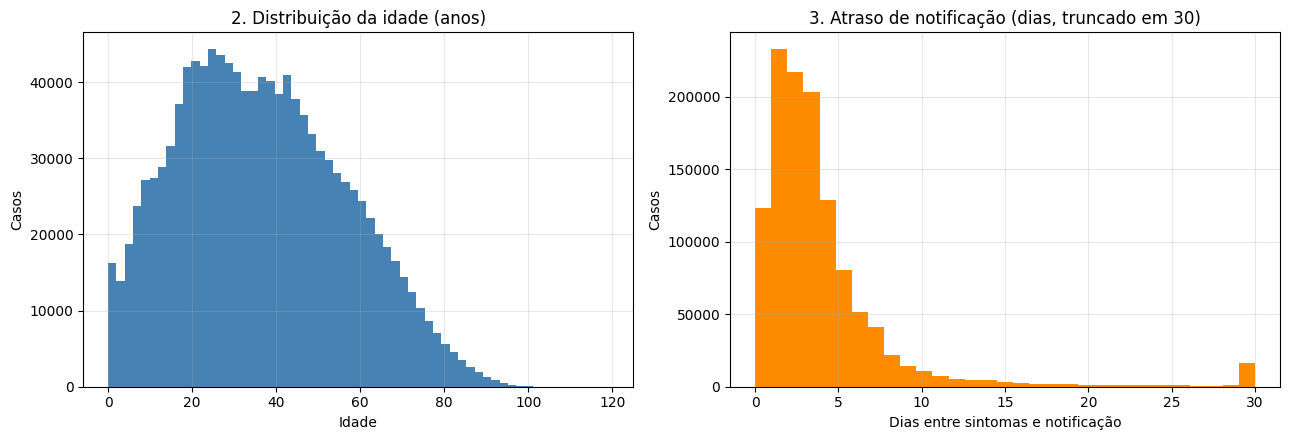

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(dev.idade_anos.dropna(), bins=60, color="steelblue"); ax[0].set_title("2. Distribuição da idade (anos)"); ax[0].set_xlabel("Idade"); ax[0].set_ylabel("Casos")
ax[1].hist(dev.atraso_notif.dropna().clip(upper=30), bins=31, color="darkorange"); ax[1].set_title("3. Atraso de notificação (dias, truncado em 30)"); ax[1].set_xlabel("Dias entre sintomas e notificação"); ax[1].set_ylabel("Casos")
plt.tight_layout(); plt.savefig(FIG/"02_03_idade_atraso_hist.png", dpi=120); plt.show()

              casos  pct_positivos
faixa_idade                       
0-4           38819           2.80
5-14         132510           2.49
15-29        310753           2.02
30-59        527609           2.39
60+          175715           3.96


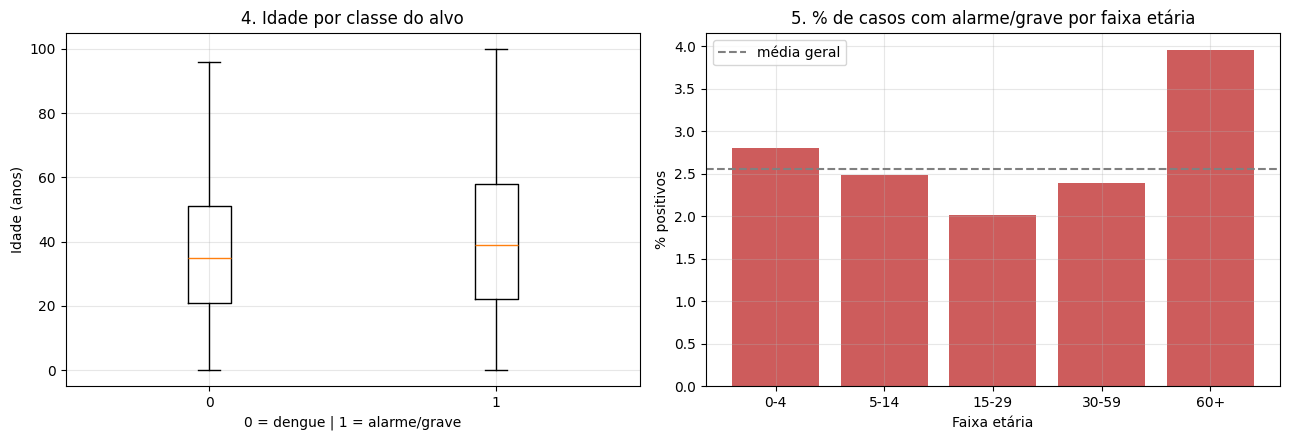

In [13]:
dev["faixa_idade"] = pd.cut(dev.idade_anos, [-1, 4, 14, 29, 59, 121], labels=["0-4","5-14","15-29","30-59","60+"])
taxa_idade = dev.groupby("faixa_idade", observed=True).y.agg(casos="size", pct_positivos=lambda s: s.mean()*100).round(2)
print(taxa_idade.to_string())
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].boxplot([dev.loc[dev.y == 0, "idade_anos"].dropna(), dev.loc[dev.y == 1, "idade_anos"].dropna()], tick_labels=["0","1"], showfliers=False); ax[0].set_title("4. Idade por classe do alvo"); ax[0].set_xlabel("0 = dengue | 1 = alarme/grave"); ax[0].set_ylabel("Idade (anos)")
barras(ax[1], taxa_idade.index, taxa_idade.pct_positivos, "5. % de casos com alarme/grave por faixa etária", "Faixa etária", "% positivos", cor="indianred", linha=dev.y.mean()*100)
plt.tight_layout(); plt.savefig(FIG/"04_05_idade_alvo.png", dpi=120); plt.show()

O boxplot mostra que a caixa dos casos positivos está deslocada para cima, e o gráfico de barras revela um padrão em "U": as crianças de 0 a 4 anos (2,8%) e principalmente os idosos com 60 anos ou mais (4,0%) têm proporção de alarme/gravidade acima da média de 2,55%, enquanto os jovens de 15 a 29 anos têm a menor (2,0%). Esse comportamento é coerente com a literatura clínica da dengue e aparece aqui só com os dados, antes de qualquer modelo.

## ETAPA 9: Análise das variáveis categóricas

Analisando sexo, gestação, raça/cor, escolaridade e região de residência, extraímos as frequências absolutas e relativas e a proporção de positivos em cada categoria:

In [14]:
dev = dev.merge(ibge[["cod_municipio","regiao"]], on="cod_municipio", how="left")
dev["regiao"] = dev.regiao.fillna("ignorado").astype("category")

def tabela_categorica(df, col):
    t = df.groupby(col, observed=True).y.agg(n="size", pct_positivos=lambda s: s.mean()*100)
    t["freq_relativa_%"] = t.n / t.n.sum() * 100
    return t.round(2).sort_values("n", ascending=False)[["n","freq_relativa_%","pct_positivos"]]

for col in ["sexo","gestante","raca","escolaridade","regiao"]:
    print(f"\n== {col}"); print(tabela_categorica(dev, col).to_string())


== sexo
           n  freq_relativa_%  pct_positivos
sexo                                        
F     644623            54.38           2.59
M     540021            45.55           2.50
I        797             0.07           1.38

== gestante
                    n  freq_relativa_%  pct_positivos
gestante                                             
nao_se_aplica  643854            54.31           2.55
nao            451527            38.09           2.66
ignorado        80968             6.83           1.75
sim              9092             0.77           4.12

== raca
               n  freq_relativa_%  pct_positivos
raca                                            
branca    589439            49.72           2.74
parda     367960            31.04           2.68
ignorado  157917            13.32           1.62
preta      53430             4.51           2.23
amarela    14477             1.22           2.80
indigena    2218             0.19           2.52

== escolaridade
           

Observando os resultados, identificamos alguns padrões: há mais casos em mulheres (54,4%) do que em homens, mas a proporção de positivos é praticamente a mesma (2,6% vs 2,5%) — o sexo, sozinho, discrimina pouco. Já a **gestação** sim: gestantes têm 4,1% de positivos, quase o dobro da média. Na raça/cor, chama atenção que a categoria "ignorado" (13,3% dos casos) tem a menor taxa (1,6%), sinal de que o preenchimento incompleto está associado a casos menos investigados — mais um motivo para manter "ignorado" como categoria e não imputar. A escolaridade é ignorada em 48,5% dos casos, o que limita seu uso.

Na geografia, a base é dominada pelo **Sudeste (71,7%)**, e só São Paulo responde por quase 60% dos casos elegíveis; a proporção de positivos, porém, é maior no Centro-Oeste (3,8%) e no Nordeste (3,4%) do que no Sudeste (2,2%). Essa diferença regional é um dos motivos para testar o enriquecimento com contexto municipal.

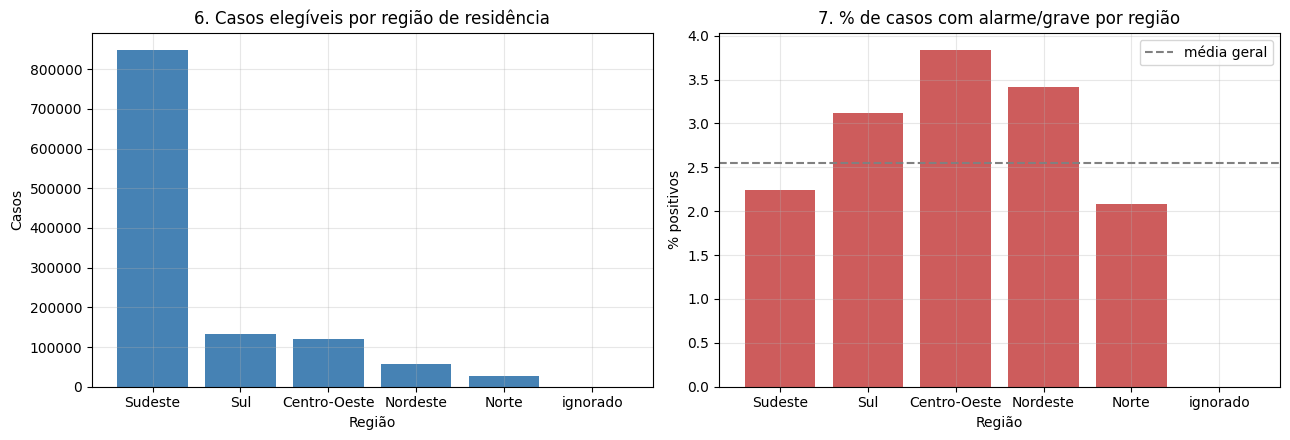

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ordem = dev.regiao.value_counts().index
barras(ax[0], ordem, dev.regiao.value_counts().loc[ordem].values, "6. Casos elegíveis por região de residência", "Região", "Casos")
t = tabela_categorica(dev, "regiao").loc[ordem]
barras(ax[1], t.index, t.pct_positivos, "7. % de casos com alarme/grave por região", "Região", "% positivos", cor="indianred", linha=dev.y.mean()*100)
plt.tight_layout(); plt.savefig(FIG/"06_07_regiao.png", dpi=120); plt.show()

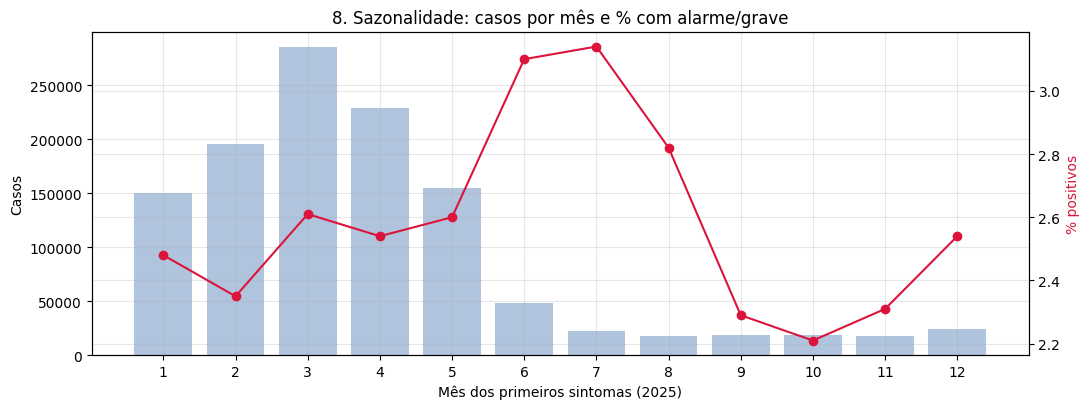

               casos  pct_positivos
mes_sintomas                       
1             150024           2.48
2             196179           2.35
3             285387           2.61
4             229309           2.54
5             155316           2.60
6              48296           3.10
7              22498           3.14
8              18141           2.82
9              19162           2.29
10             19124           2.21
11             17890           2.31
12             24115           2.54


In [16]:
t = dev.groupby("mes_sintomas").y.agg(casos="size", pct_positivos=lambda s: s.mean()*100).round(2)
fig, ax1 = plt.subplots(figsize=(11, 4.2))
ax1.bar(t.index.astype(str), t.casos, color="lightsteelblue"); ax1.set_ylabel("Casos"); ax1.set_xlabel("Mês dos primeiros sintomas (2025)")
ax2 = ax1.twinx(); ax2.plot(range(len(t)), t.pct_positivos, "o-", color="crimson"); ax2.set_ylabel("% positivos", color="crimson")
plt.title("8. Sazonalidade: casos por mês e % com alarme/grave"); plt.tight_layout(); plt.savefig(FIG/"08_sazonalidade.png", dpi=120); plt.show()
print(t.to_string())

A sazonalidade é a esperada para arboviroses: março concentra 24% dos casos e o período de janeiro a maio soma mais de 85%. A proporção de positivos, curiosamente, é maior nos meses de baixa transmissão (junho e julho, acima de 3%): na cauda da epidemia, os casos que chegam ao sistema tendem a ser os mais graves. O mês entra como atributo categórico no modelo.

## ETAPA 10: Sintomas e comorbidades em relação ao alvo

Comparamos a frequência de cada sintoma e comorbidade entre as duas classes. A leitura é descritiva — mais casos com um sinal em um grupo não significa maior risco individual (limite registrado no mapeamento) — mas já mostra quais atributos têm potencial discriminativo.

In [17]:
comp = (dev.groupby("y")[SINTOMAS + COMORB].mean()*100).T.astype("float64").round(1)
comp.columns = ["% em dengue (0)", "% em alarme/grave (1)"]
comp["diferença (p.p.)"] = (comp.iloc[:, 1] - comp.iloc[:, 0]).round(1)
comp.sort_values("diferença (p.p.)", ascending=False)

,% em dengue (0),% em alarme/grave (1),diferença (p.p.)
VOMITO,26.4,41.8,15.4
LEUCOPENIA,4.3,16.6,12.3
NAUSEA,43.9,53.6,9.7
HIPERTENSA,10.4,19.3,8.9
DIABETES,4.8,10.1,5.3
PETEQUIA_N,5.3,9.2,3.9
ARTRALGIA,17.2,20.2,3.0
EXANTEMA,8.3,10.1,1.8
RENAL,0.5,1.5,1.0
LACO,2.7,3.6,0.9


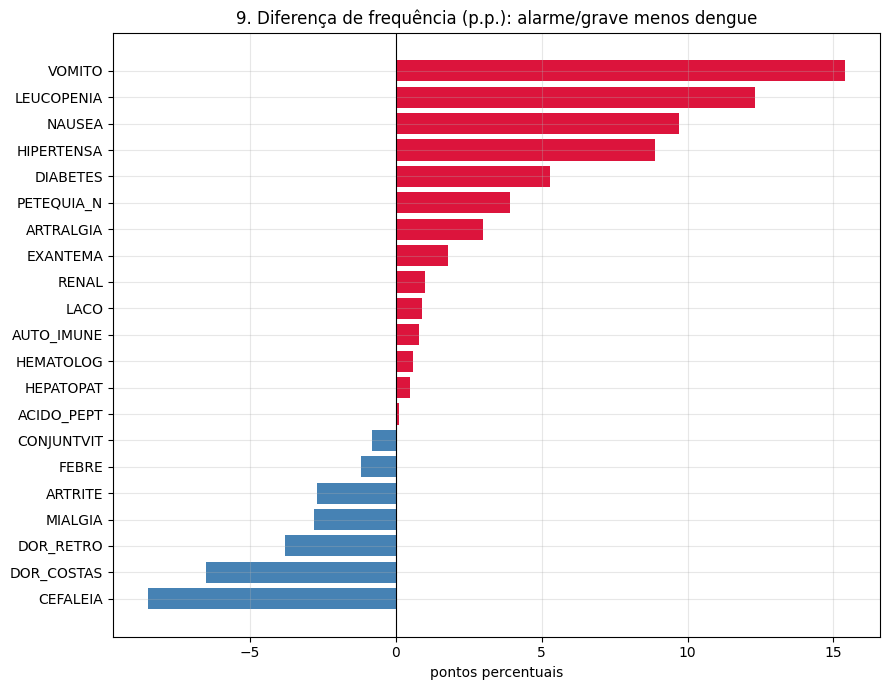

In [18]:
c = comp.sort_values("diferença (p.p.)")
plt.figure(figsize=(9, 7))
plt.barh(c.index, c["diferença (p.p.)"], color=np.where(c["diferença (p.p.)"] > 0, "crimson", "steelblue"))
plt.axvline(0, color="black", lw=0.8); plt.title("9. Diferença de frequência (p.p.): alarme/grave menos dengue"); plt.xlabel("pontos percentuais")
plt.tight_layout(); plt.savefig(FIG/"09_sintomas_diferenca.png", dpi=120); plt.show()

Os sinais que mais separam as classes são **vômito** (41,8% nos positivos contra 26,4%), **leucopenia** (16,6% contra 4,3%), **náusea**, **hipertensão** (19,3% contra 10,4%), **diabetes** (10,1% contra 4,8%) e **petéquias**. Na direção contrária, cefaleia e dor nas costas são mais frequentes nos casos sem complicação. Vômito persistente e queda de plaquetas são, de fato, sinais de alarme na definição clínica; o que a ficha registra aqui são os sintomas iniciais, mas eles antecipam o quadro. As comorbidades são raras (a maioria abaixo de 1%), mas todas mais frequentes nos positivos.

## ETAPA 11: Integração do CNES e do IBGE tratados (P05)

O CNES tratado já está em município × competência e o IBGE tratado tem uma linha por município (validados nos notebooks 02 e 03). A competência de cada caso é o mês dos primeiros sintomas; os casos das bordas (dezembro/2024 na semana 1 e janeiro/2026 na semana 53) usam a competência mais próxima disponível (jan e dez de 2025).

**Regras da junção**, seguindo a dimensão **Integração** do mapeamento: a chave é `cod_municipio` (+ competência para o CNES); exigimos unicidade do lado da dimensão (`validate="m:1"`), preservamos todos os casos (`how="left"`) e medimos correspondências e não correspondências. Um município **sem nenhum estabelecimento com leitos** não é um valor ausente: é **zero real**, e assim é registrado. Os leitos são normalizados por 10 mil habitantes para serem comparáveis entre municípios. Os indicadores de saneamento entram automaticamente quando o mapeamento do dicionário do IBGE for aprovado no notebook 03.

In [19]:
IND_SANEAMENTO = [c for c in ibge.columns if c.startswith("pct_")]
def integrar(df):
    n0 = len(df)
    df = df.merge(ibge.drop(columns=["cd_mun_ibge7","uf","regiao"]), on="cod_municipio", how="left", validate="m:1")
    sem_ibge = df.populacao.isna()
    df["competencia_cnes"] = df.competencia.clip(lower=202501, upper=202512)
    df = df.merge(cnes.rename(columns={"competencia": "competencia_cnes"}), on=["cod_municipio","competencia_cnes"], how="left", validate="m:1")
    sem_cnes = df.n_estabelecimentos.isna()
    for c in ["n_estabelecimentos","leitos","leitos_sus","leitos_uti","leitos_uti_sus"]:
        df[c] = df[c].fillna(0).astype("float32")                     # zero real: município sem estabelecimento com leitos
    for c in ["leitos","leitos_sus","leitos_uti","leitos_uti_sus"]:
        df[c + "_10k"] = (df[c] / df.populacao * 1e4).astype("float32")
    assert len(df) == n0, "a junção alterou o número de casos"
    relatorio = {"casos": n0, "sem_correspondencia_ibge": int(sem_ibge.sum()),
                 "municipios_sem_ibge": sorted(df.loc[sem_ibge, "cod_municipio"].dropna().astype(str).unique().tolist()),
                 "casos_em_municipio_sem_leitos_(zero_real)": int(sem_cnes.sum()), "pct_casos_em_municipio_sem_leitos": round(sem_cnes.mean()*100, 2),
                 "indicadores_saneamento": IND_SANEAMENTO}
    return df, relatorio

dev, rel_int = integrar(dev)
print(json.dumps(rel_int, indent=2, ensure_ascii=False))

{
  "casos": 1185441,
  "sem_correspondencia_ibge": 8,
  "municipios_sem_ibge": [
    "350000",
    "410000",
    "510183"
  ],
  "casos_em_municipio_sem_leitos_(zero_real)": 86316,
  "pct_casos_em_municipio_sem_leitos": 7.28,
  "indicadores_saneamento": []
}


Apenas 8 casos não encontram o município no IBGE: códigos do tipo `350000`/`410000` (município de residência ignorado dentro da UF) e códigos inexistentes no Censo 2022; ficam com contexto nulo, que o pipeline imputa. Já 7,3% dos casos residem em municípios sem qualquer estabelecimento com leitos cadastrados na competência — o que reforça a leitura do mapeamento de que leito cadastrado no município não significa hospital disponível: esses pacientes são atendidos em municípios vizinhos.

                        count       mean         std     min       25%        50%        75%          max
populacao           1185433.0  849413.15  2391082.24  833.00  39816.00  158647.00  480393.00  11451999.00
densidade_hab_km2   1185433.0    1160.58     2177.56    0.15     62.58     233.64    1112.17     13416.96
media_moradores     1185433.0       2.71        0.18    2.30      2.60       2.70       2.80         5.80
n_estabelecimentos  1185441.0      20.94       50.28    0.00      1.00       4.00      14.00       226.00
leitos_10k          1185433.0      27.90       19.33    0.00     15.76      25.06      35.51       327.07
leitos_sus_10k      1185433.0      17.59       12.76    0.00     10.20      15.20      23.68       227.24
leitos_uti_10k      1185433.0       3.44        2.97    0.00      0.00       3.06       5.63        40.49
leitos_uti_sus_10k  1185433.0       1.84        1.65    0.00      0.00       1.94       2.63        37.26

% positivos por faixa de leitos existentes po

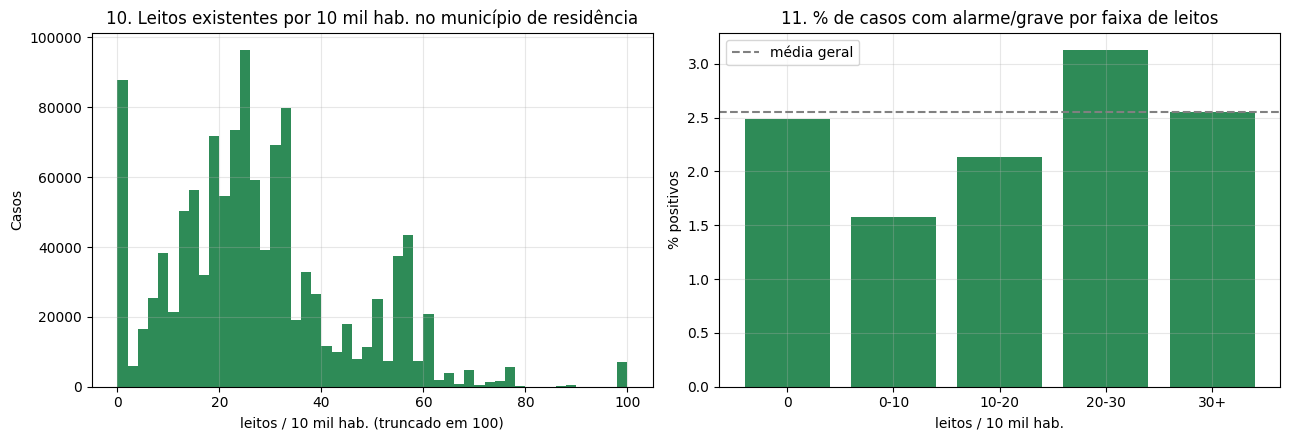

In [20]:
NUM_CTX = ["leitos_10k","leitos_sus_10k","leitos_uti_10k","leitos_uti_sus_10k","n_estabelecimentos","densidade_hab_km2","media_moradores","populacao"] + IND_SANEAMENTO
print(dev[["populacao","densidade_hab_km2","media_moradores","n_estabelecimentos","leitos_10k","leitos_sus_10k","leitos_uti_10k","leitos_uti_sus_10k"]].describe().round(2).T.to_string())
dev["faixa_leitos"] = pd.cut(dev.leitos_10k, [-0.1, 0, 10, 20, 30, 1e9], labels=["0","0-10","10-20","20-30","30+"])
t = dev.groupby("faixa_leitos", observed=True).y.agg(casos="size", pct_positivos=lambda s: s.mean()*100).round(2)
print("\n% positivos por faixa de leitos existentes por 10 mil habitantes:"); print(t.to_string())
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(dev.leitos_10k.clip(upper=100), bins=50, color="seagreen"); ax[0].set_title("10. Leitos existentes por 10 mil hab. no município de residência"); ax[0].set_xlabel("leitos / 10 mil hab. (truncado em 100)"); ax[0].set_ylabel("Casos")
barras(ax[1], t.index, t.pct_positivos, "11. % de casos com alarme/grave por faixa de leitos", "leitos / 10 mil hab.", "% positivos", cor="seagreen", linha=dev.y.mean()*100)
plt.tight_layout(); plt.savefig(FIG/"10_11_leitos.png", dpi=120); plt.show()

A relação entre capacidade instalada e proporção de positivos não é monotônica: municípios sem leitos e municípios com mais de 30 leitos por 10 mil habitantes ficam próximos da média, enquanto a faixa de 20 a 30 tem a maior proporção. A interpretação mais provável é que o registro de alarme e gravidade depende da capacidade de **investigar** o caso, que é maior onde há hospitais de médio porte; onde não há leitos, casos graves podem ser notificados e classificados em outro município. É exatamente o tipo de contexto que o modelo enriquecido testa, e também um limite: a variável descreve o município, não o atendimento do paciente.

## ETAPA 12: Correlação com o alvo

Calculamos o coeficiente de Pearson entre cada atributo numérico (incluindo os sintomas e comorbidades em 0/1) e o alvo. Com alvo binário, o valor coincide com a correlação ponto-bisserial; ele mede associação linear e não causa.

CEFALEIA             -0.034
DOR_COSTAS           -0.023
ARTRITE              -0.014
DOR_RETRO            -0.013
MIALGIA              -0.011
CONJUNTVIT           -0.007
FEBRE                -0.006
populacao            -0.005
ACIDO_PEPT            0.001
n_estabelecimentos    0.001
media_moradores       0.002
LACO                  0.009
leitos_sus_10k        0.010
EXANTEMA              0.010
HEPATOPAT             0.012
ARTRALGIA             0.013
HEMATOLOG             0.013
densidade_hab_km2     0.014
leitos_10k            0.014
AUTO_IMUNE            0.016
RENAL                 0.022
leitos_uti_sus_10k    0.023
atraso_notif          0.024
leitos_uti_10k        0.025
PETEQUIA_N            0.027
NAUSEA                0.031
idade_anos            0.032
DIABETES              0.039
HIPERTENSA            0.046
VOMITO                0.055
LEUCOPENIA            0.093


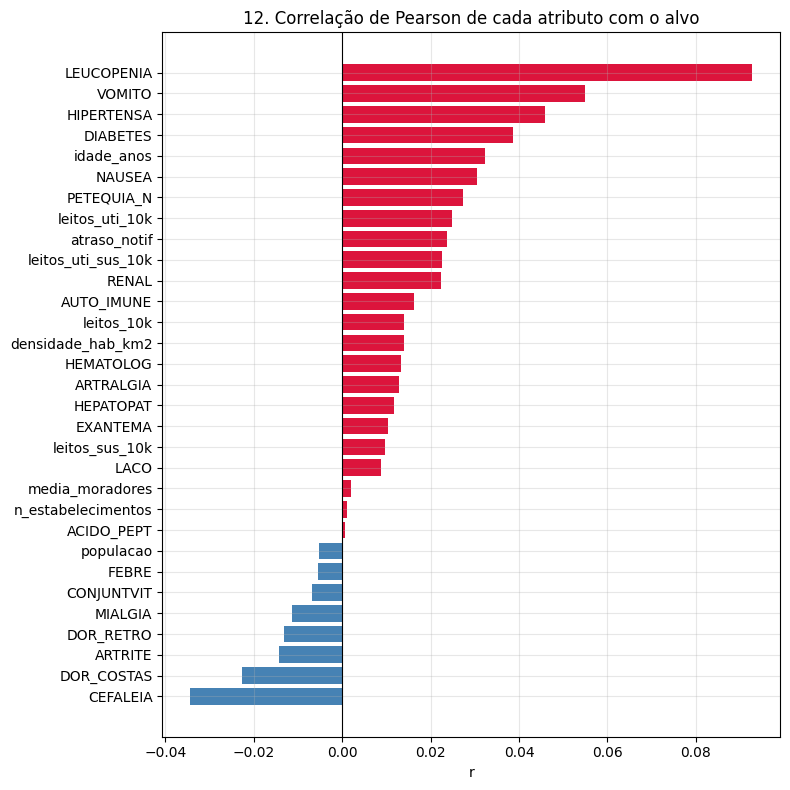

In [21]:
num_cols = ["idade_anos","atraso_notif"] + SINTOMAS + COMORB + NUM_CTX
corr_alvo = dev[num_cols + ["y"]].corr()["y"].drop("y").sort_values()
print(corr_alvo.round(3).to_string())
plt.figure(figsize=(8, 8))
plt.barh(corr_alvo.index, corr_alvo.values, color=np.where(corr_alvo.values > 0, "crimson", "steelblue"))
plt.axvline(0, color="black", lw=0.8); plt.title("12. Correlação de Pearson de cada atributo com o alvo"); plt.xlabel("r")
plt.tight_layout(); plt.savefig(FIG/"12_correlacao_alvo.png", dpi=120); plt.show()

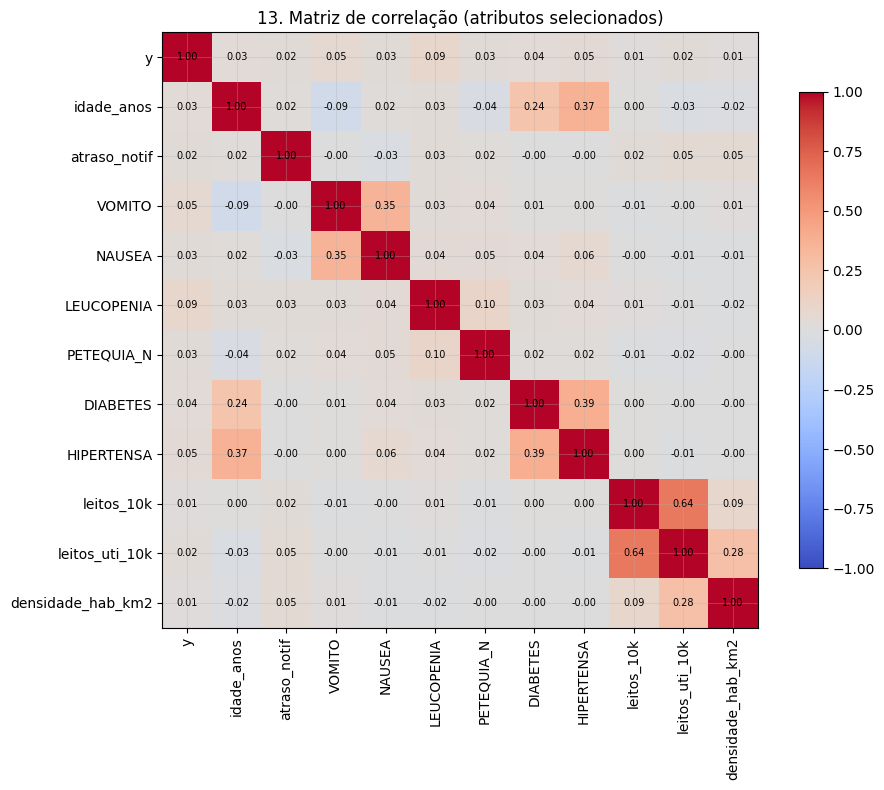

In [22]:
sel = ["y","idade_anos","atraso_notif","VOMITO","NAUSEA","LEUCOPENIA","PETEQUIA_N","DIABETES","HIPERTENSA","leitos_10k","leitos_uti_10k","densidade_hab_km2"]
plt.figure(figsize=(10, 8))
M = dev[sel].corr(); im = plt.imshow(M, cmap="coolwarm", vmin=-1, vmax=1); plt.colorbar(im, shrink=.8)
plt.xticks(range(len(sel)), sel, rotation=90); plt.yticks(range(len(sel)), sel)
for i in range(len(sel)):
    for j in range(len(sel)): plt.text(j, i, f"{M.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.title("13. Matriz de correlação (atributos selecionados)"); plt.tight_layout(); plt.savefig(FIG/"13_heatmap_corr.png", dpi=120); plt.show()

Todas as correlações individuais são fracas (a maior é leucopenia, r = 0,09), o que é típico de um alvo raro e multifatorial: nenhum atributo isolado explica a classificação, e por isso o método escolhido combina todos eles. A matriz também mostra que os atributos de contexto são correlacionados entre si (leitos e UTI por 10 mil, por exemplo), um cuidado para a leitura dos coeficientes da regressão logística, que "depende da codificação e da correlação entre atributos", como o mapeamento antecipou.

## ETAPA 13: Preparação para o treinamento e ajuste inicial (P05 / P07)

A limpeza transformou os brutos em bases utilizáveis; esta etapa adapta a base analítica ao método, seguindo a tabela da seção 3 do roteiro complementar. Cada decisão está registrada antes do ajuste:

| Atividade | Decisão aplicada |
|---|---|
| Definir população elegível | Só CLASSI_FIN 10, 11 e 12 (feito na limpeza, conferido na Etapa 4). |
| Evitar vazamento | Alarme, gravidade, desfecho, laboratoriais e infecção fora dos preditores (Etapa 5). |
| Codificar categorias | One-hot para sexo, gestação, raça, escolaridade, mês, UF e região, com "ignorado" e "não se aplica" como categorias próprias; categorias com menos de 50 ocorrências agrupadas em "infrequente". |
| Tratar ausências | Regras derivadas da EDA (Etapa 7): sintomas e comorbidades nulos recebem a moda **e um indicador de imputação**, para que ausente não vire "não" sem marca; idade, atraso e contexto municipal nulos recebem a mediana, também com indicador. Nada é imputado nas categóricas. |
| Separar conjuntos | Teste (20%) reservado na Etapa 6; o desenvolvimento é dividido em treino (80%) e validação (20%), estratificados; a validação serve às decisões de desenvolvimento, o teste só a P08. |
| Padronizar quando necessário | Apenas as variáveis contínuas (idade, atraso, população, densidade, leitos por 10 mil…) são padronizadas, porque estão em escalas muito diferentes e o L-BFGS converge melhor; os 0/1 e os indicadores não são padronizados. Todo parâmetro é aprendido no treino. |

Tudo isso vive dentro de um `Pipeline` do scikit-learn, **ajustado apenas no treino** e aplicado com as mesmas regras à validação. O modelo é a **Regressão Logística** com `class_weight="balanced"`, que repondera os 2,55% de positivos para que o ajuste não os ignore. Comparamos os dois conjuntos de atributos previstos no objetivo específico:

1. **SINAN isolado:** idade, atraso, sintomas, comorbidades, sexo, gestação, raça, escolaridade, mês e UF de residência.
2. **SINAN enriquecido:** os mesmos, mais leitos, leitos SUS, UTI e UTI SUS por 10 mil habitantes, estabelecimentos, população, densidade, média de moradores e região (CNES + IBGE), e os indicadores de saneamento quando aprovados.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

BIN_SINAN = SINTOMAS + COMORB
CONT_SINAN = ["idade_anos","atraso_notif"]
CAT_SINAN = ["sexo","gestante","raca","escolaridade","uf_res","mes_sintomas"]
CONT_ENRIQ = CONT_SINAN + NUM_CTX
CAT_ENRIQ = CAT_SINAN + ["regiao"]
NUM_SINAN, NUM_ENRIQ = CONT_SINAN + BIN_SINAN, CONT_ENRIQ + BIN_SINAN
CONJUNTOS = {"SINAN isolado": (BIN_SINAN, CONT_SINAN, CAT_SINAN), "SINAN + CNES + IBGE": (BIN_SINAN, CONT_ENRIQ, CAT_ENRIQ)}

def construir_pipeline(binarias, continuas, categoricas):
    pre = ColumnTransformer([
        ("bin",  SimpleImputer(strategy="most_frequent", add_indicator=True), binarias),                               # 0/1: moda + indicador de imputação, sem padronizar
        ("cont", Pipeline([("imputar", SimpleImputer(strategy="median", add_indicator=True)), ("escalar", StandardScaler())]), continuas),
        ("cat",  OneHotEncoder(handle_unknown="ignore", min_frequency=50), categoricas)])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"))])

colunas_base = ["id_registro","y","CLASSI_FIN","DT_SIN_PRI","cod_municipio","competencia","nome_municipio","regiao"] + NUM_ENRIQ + CAT_SINAN
dev = dev[colunas_base].copy()
dev.to_parquet(PROC/"base_analitica_dev.parquet", index=False)

treino, valid = train_test_split(dev, test_size=0.20, stratify=dev.y, random_state=SEED)
print(f"treino: {len(treino):,} ({treino.y.mean()*100:.2f}% pos.) | validação: {len(valid):,} ({valid.y.mean()*100:.2f}% pos.)")

treino: 948,352 (2.55% pos.) | validação: 237,089 (2.55% pos.)


In [24]:
def avaliar(modelo, X, y, limiar=0.5):
    p = modelo.predict_proba(X)[:, 1]
    yh = (p >= limiar).astype(int)
    return {"acuracia": accuracy_score(y, yh), "acuracia_balanceada": balanced_accuracy_score(y, yh),
            "precisao": precision_score(y, yh), "recall": recall_score(y, yh), "f1": f1_score(y, yh),
            "auc_roc": roc_auc_score(y, p), "auc_pr": average_precision_score(y, p)}, p

modelos, resultados, probs = {}, {}, {}
for nome, (b, ct, cat) in CONJUNTOS.items():
    t = time.time(); cols = b + ct + cat
    m = construir_pipeline(b, ct, cat).fit(treino[cols], treino.y)
    r, p = avaliar(m, valid[cols], valid.y)
    modelos[nome], resultados[nome], probs[nome] = m, r, p
    print(f"{nome:22s} ajustado em {time.time()-t:.0f} s | atributos após pré-processamento: {m[-1].n_features_in_}")

tabela_res = pd.DataFrame(resultados).T.round(4)
tabela_res.to_csv(PROC/"metricas_validacao.csv")
tabela_res

SINAN isolado          ajustado em 23 s | atributos após pré-processamento: 107


SINAN + CNES + IBGE    ajustado em 34 s | atributos após pré-processamento: 128


,acuracia,acuracia_balanceada,precisao,recall,f1,auc_roc,auc_pr
SINAN isolado,0.7002,0.6616,0.0518,0.6210,0.0956,0.7212,0.0766
SINAN + CNES + IBGE,0.7080,0.6770,0.0549,0.6443,0.1012,0.7364,0.0796


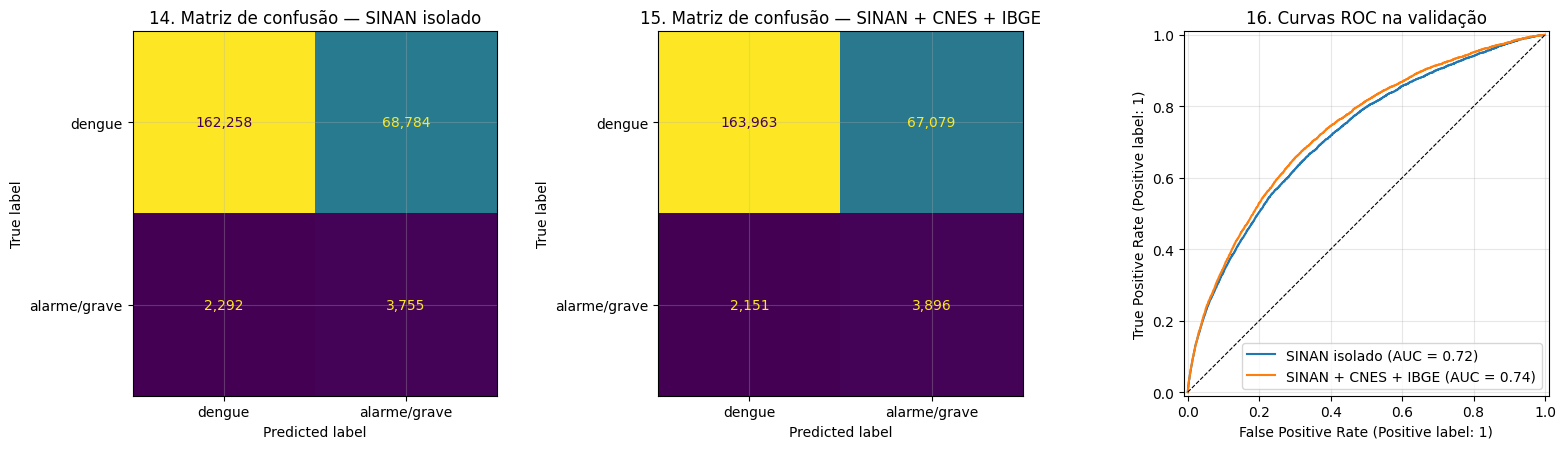

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for i, nome in enumerate(CONJUNTOS):
    ConfusionMatrixDisplay.from_predictions(valid.y, (probs[nome] >= 0.5).astype(int), display_labels=["dengue","alarme/grave"], colorbar=False, ax=ax[i], values_format=",d")
    ax[i].set_title(f"{14+i}. Matriz de confusão — {nome}")
for nome in CONJUNTOS:
    RocCurveDisplay.from_predictions(valid.y, probs[nome], name=nome, ax=ax[2])
ax[2].plot([0, 1], [0, 1], "k--", lw=0.8); ax[2].set_title("16. Curvas ROC na validação")
plt.tight_layout(); plt.savefig(FIG/"14_16_confusao_roc.png", dpi=120); plt.show()

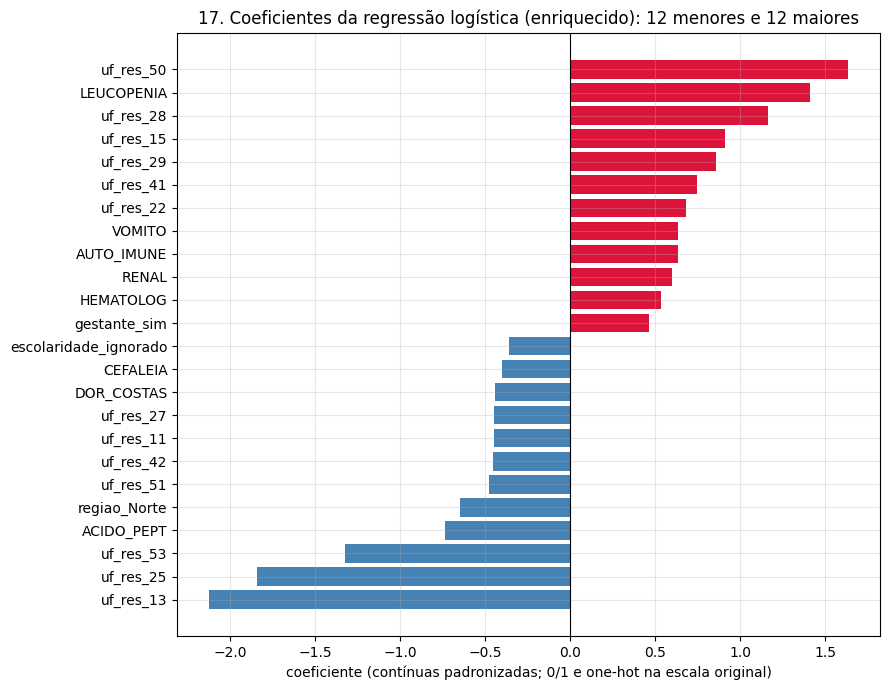

In [26]:
def coeficientes(modelo, k=12):
    nomes = modelo["pre"].get_feature_names_out()
    co = pd.Series(modelo["clf"].coef_[0], index=[n.split("__", 1)[1] for n in nomes]).sort_values()
    return pd.concat([co.head(k), co.tail(k)])

co = coeficientes(modelos["SINAN + CNES + IBGE"])
plt.figure(figsize=(9, 7))
plt.barh(co.index, co.values, color=np.where(co.values > 0, "crimson", "steelblue"))
plt.axvline(0, color="black", lw=0.8); plt.title("17. Coeficientes da regressão logística (enriquecido): 12 menores e 12 maiores"); plt.xlabel("coeficiente (contínuas padronizadas; 0/1 e one-hot na escala original)")
plt.tight_layout(); plt.savefig(FIG/"17_coeficientes.png", dpi=120); plt.show()

Os coeficientes não são efeitos causais, mas confirmam o que a exploração mostrou: leucopenia, vômito, petéquias, gestação, idade e as comorbidades empurram a probabilidade para cima; cefaleia e dor nas costas, para baixo. Entre os atributos de contexto, região e leitos por 10 mil habitantes aparecem com peso moderado. O enriquecimento com CNES e IBGE melhora todas as métricas de ordenação (AUC-ROC de 0,721 para 0,736 e AUC-PR de 0,077 para 0,080) — um ganho pequeno, mas consistente, que será reavaliado com os indicadores de saneamento e no teste final.

## ETAPA 14: Como a acurácia será calculada — método de avaliação

O método foi definido **antes** do treinamento, como pede a seção 5 do roteiro complementar, para não escolher métricas depois de ver os resultados. As cinco medidas do protocolo partem da matriz de confusão obtida ao comparar classe prevista e classe real, com a classe prevista igual a 1 quando a probabilidade estimada é maior ou igual ao limiar (0,5 nesta etapa):

| Métrica | Fórmula | Uso no projeto |
|---|---|---|
| Matriz de confusão | VP, FP, FN, VN | acertos e erros por classe, incluindo falsos positivos e falsos negativos |
| **Acurácia** | (VP + VN) / (VP + VN + FP + FN) | proporção total de classificações corretas — a medida exigida pela disciplina |
| Precisão | VP / (VP + FP) | entre os previstos como positivos, quantos realmente são alarme/grave |
| Recall (sensibilidade) | VP / (VP + FN) | dos casos de alarme/grave, quantos o modelo identificou |
| F1-score | 2·precisão·recall / (precisão + recall) | síntese de precisão e recall, útil com o desequilíbrio de 2,55% |

A acurácia é entendida como a razão entre classificações corretas e o total de casos avaliados, mas **não será usada sozinha**: com 2,55% de positivos, um classificador que dissesse "dengue" para todos teria 97,45% de acurácia. Como apoio à leitura, e sem substituir o protocolo, reportamos também a acurácia balanceada (média de sensibilidade e especificidade) e as áreas sob as curvas ROC e precisão-recall, que independem do limiar.

**Critério de honestidade.** Não foi fixado desempenho mínimo nem se promete utilidade clínica; resultados baixos e limitações são reportados como estão. O limiar será escolhido na validação segundo o uso pretendido, e as métricas serão calculadas **uma única vez** no conjunto de teste reservado, em P08, com o mesmo pipeline e a mesma semente.

In [27]:
for nome in CONJUNTOS:
    vn, fp, fn, vp = confusion_matrix(valid.y, (probs[nome] >= 0.5).astype(int)).ravel()
    print(f"{nome:22s} VP={vp:,} FP={fp:,} FN={fn:,} VN={vn:,} -> acurácia={(vp+vn)/(vp+vn+fp+fn):.4f} | sensibilidade={vp/(vp+fn):.4f} | especificidade={vn/(vn+fp):.4f}")

# efeito do limiar (só validação): precisão e recall para alguns cortes
p = probs["SINAN + CNES + IBGE"]
lim = pd.DataFrame([{"limiar": l, "acuracia": accuracy_score(valid.y, p >= l), "precisao": precision_score(valid.y, p >= l), "recall": recall_score(valid.y, p >= l),
                     "f1": f1_score(valid.y, p >= l), "alertas_%": (p >= l).mean()*100} for l in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]]).round(3)
lim

SINAN isolado          VP=3,755 FP=68,784 FN=2,292 VN=162,258 -> acurácia=0.7002 | sensibilidade=0.6210 | especificidade=0.7023
SINAN + CNES + IBGE    VP=3,896 FP=67,079 FN=2,151 VN=163,963 -> acurácia=0.7080 | sensibilidade=0.6443 | especificidade=0.7097


,limiar,acuracia,precisao,recall,f1,alertas_%
0,0.3,0.316,0.033,0.915,0.064,70.476
1,0.4,0.536,0.042,0.797,0.080,47.955
2,0.5,0.708,0.055,0.644,0.101,29.936
3,0.6,0.829,0.070,0.466,0.122,16.922
4,0.7,0.906,0.091,0.302,0.140,8.436
5,0.8,0.949,0.124,0.166,0.142,3.396


In [28]:
resumo_exec = {"casos_elegiveis_total": int(len(ids_dev) + len(ids_test)), "desenvolvimento": int(len(ids_dev)), "teste_reservado": int(len(ids_test)),
               "treino": int(len(treino)), "validacao": int(len(valid)), "pct_positivos": round(float(dev.y.mean()*100), 2),
               "seed": SEED, "integracao": rel_int, "metricas_validacao": {k: {m: round(v, 4) for m, v in r.items()} for k, r in resultados.items()},
               "versoes": {m.__name__: m.__version__ for m in (np, pd, sklearn, matplotlib)}}
(PROC/"resumo_integracao_modelo.json").write_text(json.dumps(resumo_exec, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(resumo_exec["metricas_validacao"], indent=2))

{
  "SINAN isolado": {
    "acuracia": 0.7002,
    "acuracia_balanceada": 0.6616,
    "precisao": 0.0518,
    "recall": 0.621,
    "f1": 0.0956,
    "auc_roc": 0.7212,
    "auc_pr": 0.0766
  },
  "SINAN + CNES + IBGE": {
    "acuracia": 0.708,
    "acuracia_balanceada": 0.677,
    "precisao": 0.0549,
    "recall": 0.6443,
    "f1": 0.1012,
    "auc_roc": 0.7364,
    "auc_pr": 0.0796
  }
}


## CONCLUSÃO

Após a exploração e a preparação dos dados tabulares, podemos concluir que:

**Principais padrões encontrados:** a base elegível tem 1,48 milhão de casos com apenas 2,55% de dengue com sinais de alarme ou grave — um alvo raro e desequilibrado. A proporção de positivos cresce nos extremos de idade (4,0% acima de 60 anos), em gestantes (4,1%), nos casos com vômito, leucopenia, náusea e petéquias na ficha, e nas comorbidades (hipertensão e diabetes com o dobro da frequência). Geograficamente, o Sudeste concentra 72% dos casos, mas Centro-Oeste e Nordeste têm proporções de positivos maiores. A sazonalidade é a esperada, com pico em março.

**Insights relevantes:** os sinais de alarme e gravidade da ficha separam quase perfeitamente as classes porque são a própria definição do alvo, e por isso foram excluídos dos preditores — a decisão mais importante de validade temporal do projeto. As correlações individuais são todas fracas (máximo de 0,09), o que justifica um modelo que combine os atributos. Na validação, a regressão logística com ponderação de classes alcança AUC-ROC de 0,72 só com o SINAN e 0,74 com CNES e IBGE: o contexto municipal contribui, mas pouco, e os atributos clínicos dominam.

**Possíveis aplicações práticas:** um escore calculado no momento da notificação poderia apoiar a priorização de acompanhamento e o planejamento de leitos nos meses de pico — aplicação potencial, sem promessa de utilidade clínica nesta etapa. O ganho do enriquecimento sugere que informações territoriais mais específicas (saneamento, acesso regional a hospitais) merecem ser testadas.

**Limitações da análise:** associações não são causa; a classificação depende da qualidade da investigação de cada município (a categoria "ignorado" tem a menor proporção de positivos, sinal desse viés); leitos cadastrados não são leitos disponíveis e descrevem o município de residência, não o atendimento; os indicadores de saneamento aguardam o mapeamento do dicionário do IBGE; a forma linear da regressão logística pode não captar interações (idade × comorbidade, por exemplo). O conjunto de teste permanece fechado até P08.

**Próximos passos (Etapa 3):** aprovar o mapeamento do dicionário do IBGE (notebook 03) para incluir água, esgoto e lixo; colocar os 17 informes em `db/bases_brutas/informes/` e executar o notebook 04, depois a análise textual (P06); ajustar o limiar e comparar candidatos na validação (P07); avaliar uma única vez no teste, interpretar e comunicar (P08).